In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define absolute path for data source
# Note: Using absolute path to ensure environment-independent file resolution
file_path = "/Users/mennatarek/Desktop/product-performance-intelligence/Sample - Superstore.csv"

# Load dataset with specific encoding to handle special characters
try:
    df = pd.read_csv(file_path, encoding='latin1')
    print(f"Dataset loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print("Error: The file was not found at the specified path.")

Dataset loaded successfully. Shape: (9994, 21)


In [6]:
df.shape

(9994, 21)

In [3]:
# 1. DATA PREPROCESSING & INTEGRITY

# Standardize temporal fields to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Validate data integrity by removing null entries
# Note: Cleaning step ensures downstream analytical consistency
df = df.dropna()

# 2. FEATURE ENGINEERING

# Calculate Profit Margin via vectorized conditional logic
# np.where handles zero-division edge cases for Sales records
df['Profit Margin'] = np.where(df['Sales'] != 0, df['Profit'] / df['Sales'], 0)

# Validate transformation output
print(f"Preprocessing complete. Current dataset shape: {df.shape}")
display(df.head()) 

Preprocessing complete. Current dataset shape: (9994, 22)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125


In [4]:

# 3. MULTI-DIMENSIONAL BUSINESS ANALYSIS

# A) Product Performance: Identify primary profit drivers and negative profit products
# Aggregating total profit by product name for performance ranking
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)

print("Executive Summary: Top 5 High-Performing Products")
display(product_profit.head(5).to_frame())

print("\nExecutive Summary: Bottom 5 Under-Performing Products")
display(product_profit.tail(5).to_frame())

# B) Regional Evaluation: Comparative Sales vs. Profit metrics. Putting Sales and Profit side-by-side # Sorting by Profit to evaluate regional operational efficiency
regional_analysis = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)
print("\nRegional Operational Performance Metrics:")
display(regional_analysis)

# C) Discount Optimization: Correlation between discount rates and margins
# Calculating mean Profit Margin to assess the impact of discounting strategies
discount_analysis = df.groupby('Discount')['Profit Margin'].mean().reset_index()
print("\nMean Profit Margin by Discount Tier:")
display(discount_analysis.head(10))

# 4. DATA EXPORT & BI INTEGRATION

import os

# Verify current working directory for environment logging
print(f"Current System Directory: {os.getcwd()}")

# Export cleaned dataset via absolute path for downstream BI consumption
# Path ensures consistency across local and cloud-integrated environments
export_path = "/Users/mennatarek/Desktop/product-performance-intelligence/cleaned_superstore.csv"

try:
    df.to_csv(export_path, index=False)
    print(f"\nSUCCESS: Cleaned dataset exported to: {export_path}")
except Exception as e:
    print(f"Export Error: {e}")

Executive Summary: Top 5 High-Performing Products


,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766



Executive Summary: Bottom 5 Under-Performing Products


,Profit
Product Name,
Bush Advantage Collection Racetrack Conference Table,-1934.3976
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
Cubify CubeX 3D Printer Double Head Print,-8879.9704



Regional Operational Performance Metrics:


,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625



Mean Profit Margin by Discount Tier:


,Discount,Profit Margin
0,0.00,0.340160
1,0.10,0.155792
2,0.15,0.034163
3,0.20,0.176839
4,0.30,-0.115481
5,0.32,-0.174292
6,0.40,-0.222492
7,0.45,-0.454545
8,0.50,-0.549091
9,0.60,-0.689130


Current System Directory: /Users/mennatarek/Desktop/product-performance-intelligence

SUCCESS: Cleaned dataset exported to: /Users/mennatarek/Desktop/product-performance-intelligence/cleaned_superstore.csv


In [9]:
%pip install seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/var/folders/t0/fmx45w2n48bg0r70vjf4qy7c0000gq/T/ipykernel_4244/3776403174.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_profit.values, y=subcat_profit.index, palette="viridis")


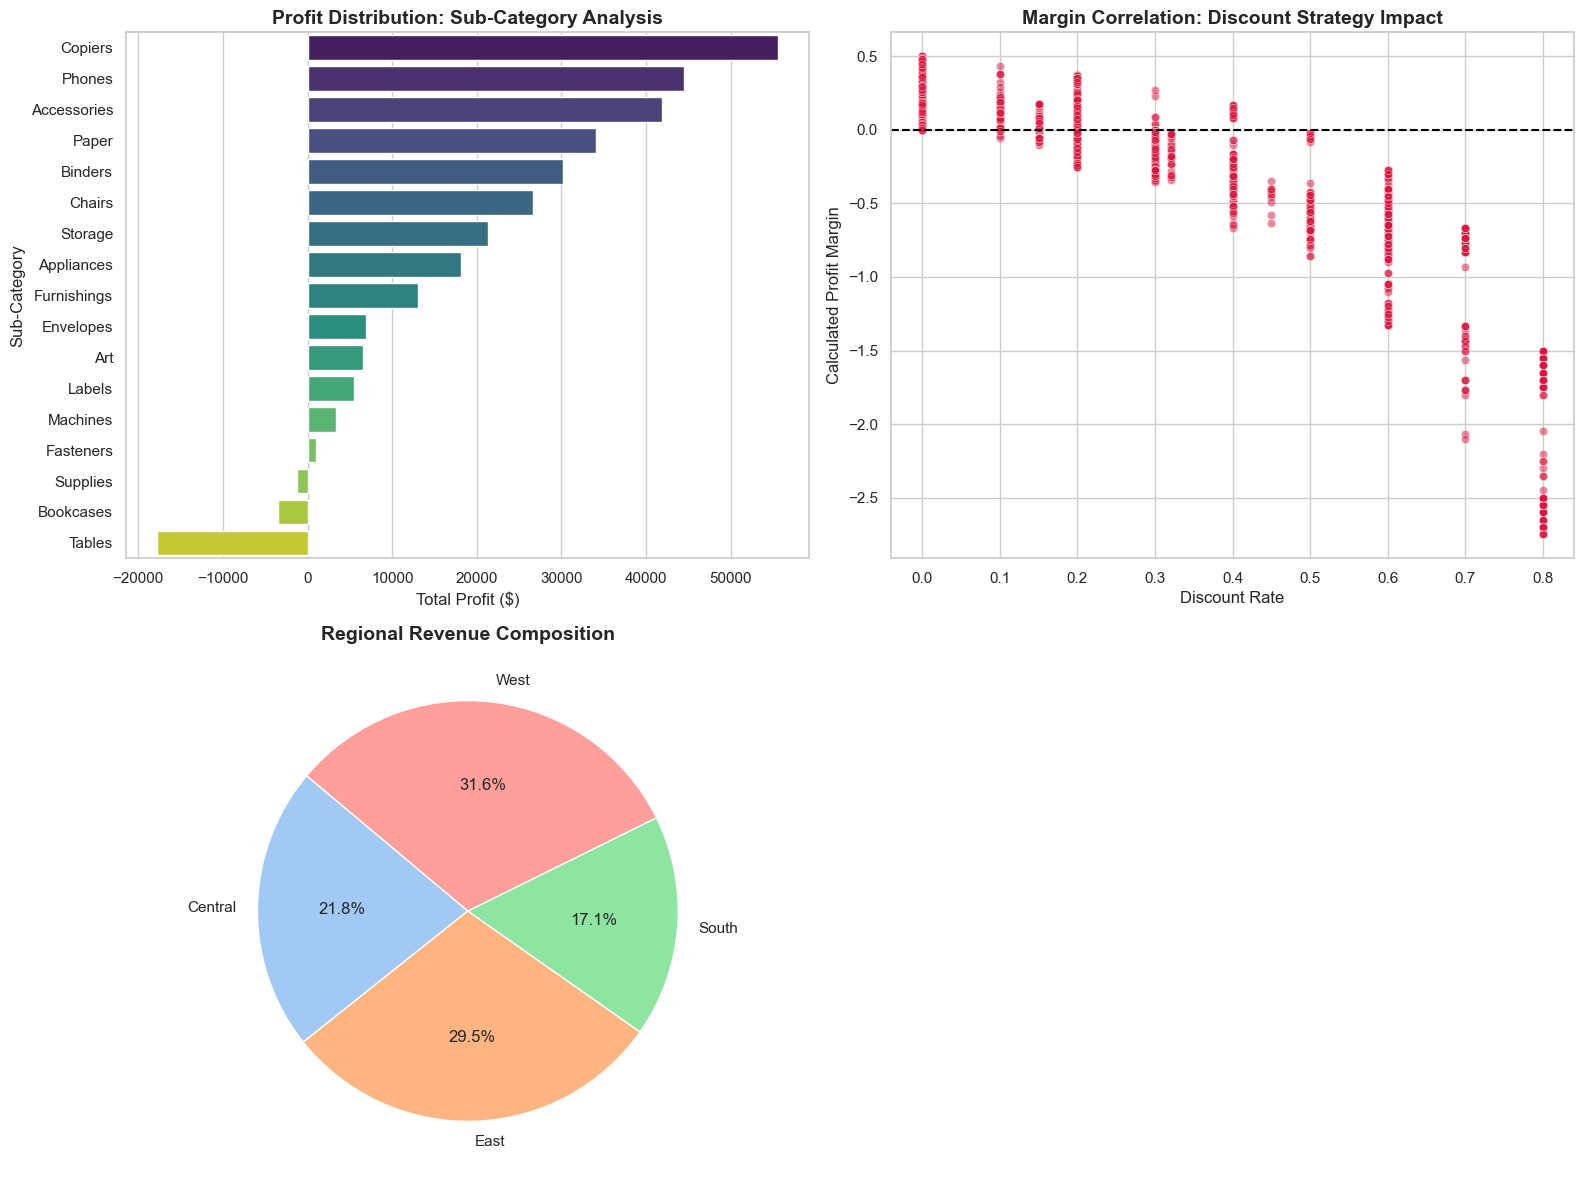

In [6]:

# 5. BUSINESS INTELLIGENCE VISUALIZATIONS
import matplotlib.pyplot as plt
import seaborn as sns

# Configure global visualization parameters for professional reporting
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# A) Categorical Performance: Profitability by Sub-Category
# Purpose: Identify high-performing product segments for resource allocation
plt.subplot(2, 2, 1)
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=subcat_profit.values, y=subcat_profit.index, palette="viridis")
plt.title("Profit Distribution: Sub-Category Analysis", fontsize=14, fontweight='bold')
plt.xlabel("Total Profit ($)")
plt.ylabel("Sub-Category")

# B) Correlation Analysis: Impact of Discounting on Operational Margins
# Purpose: Visualize the 'Discount Trap' through scatter distribution
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='Discount', y='Profit Margin', alpha=0.5, color='crimson')
plt.axhline(0, color='black', linestyle='--') # Baseline indicator for break-even point
plt.title("Margin Correlation: Discount Strategy Impact", fontsize=14, fontweight='bold')
plt.xlabel("Discount Rate")
plt.ylabel("Calculated Profit Margin")

# C) Market Composition: Regional Revenue Contribution
# Purpose: Assessment of market share distribution across active regions
plt.subplot(2, 2, 3)
region_sales = df.groupby('Region')['Sales'].sum()
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Regional Revenue Composition", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

/var/folders/t0/fmx45w2n48bg0r70vjf4qy7c0000gq/T/ipykernel_4244/2892535460.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_profit.index, y=segment_profit.values, palette="magma")


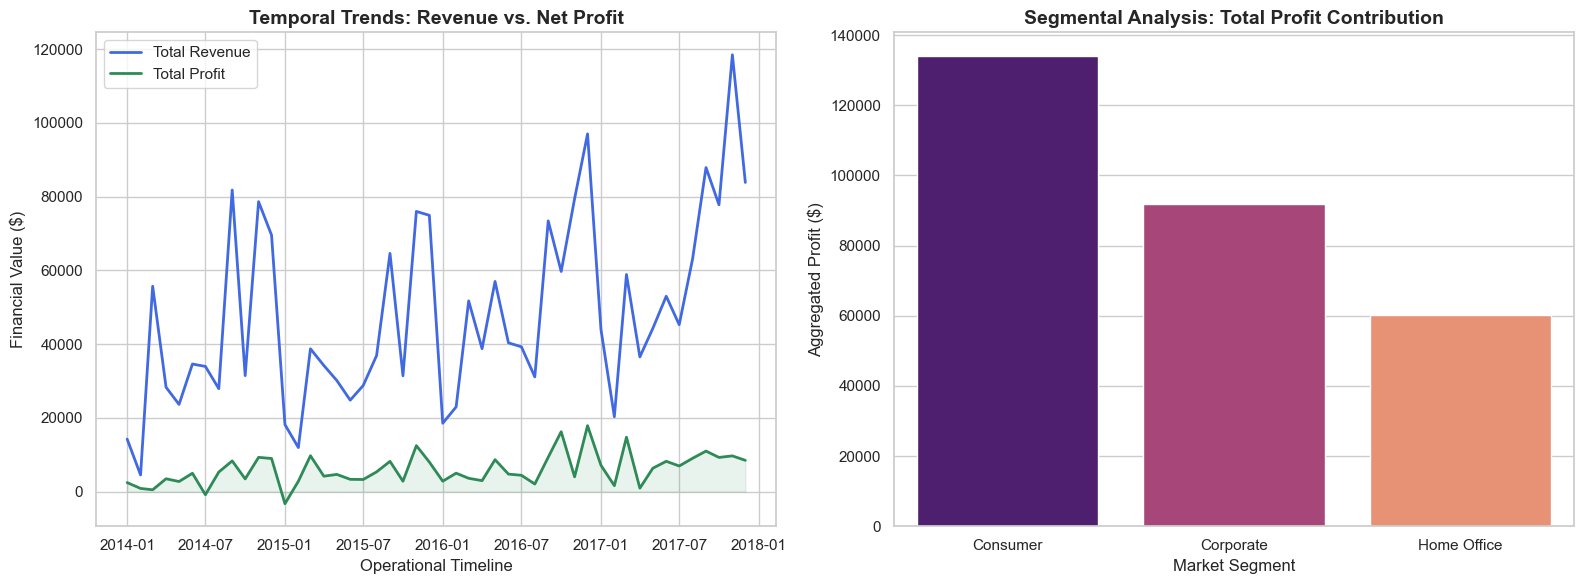

In [8]:

# 6. ADVANCED MARKETING & TEMPORAL ANALYSIS

# Convert text to dates so Python can plot them on a timeline
df['Order Date'] = pd.to_datetime(df['Order Date'])

plt.figure(figsize=(16, 6))

# A) Time-Series Analysis: Revenue and Profitability Seasonality
plt.subplot(1, 2, 1)

# Grouping data by month to see trends more clearly
monthly_trend = df.groupby(df['Order Date'].dt.to_period('M'))[['Sales', 'Profit']].sum().reset_index()
monthly_trend['Order Date'] = monthly_trend['Order Date'].dt.to_timestamp()

# Drawing two lines to compare total sales vs. total profit
sns.lineplot(data=monthly_trend, x='Order Date', y='Sales', label='Total Revenue', color='royalblue', linewidth=2)
sns.lineplot(data=monthly_trend, x='Order Date', y='Profit', label='Total Profit', color='seagreen', linewidth=2)

# Fill the area under the profit line to make it stand out
plt.fill_between(monthly_trend['Order Date'], monthly_trend['Profit'], color='seagreen', alpha=0.1)

plt.title("Temporal Trends: Revenue vs. Net Profit", fontsize=14, fontweight='bold')
plt.xlabel("Operational Timeline")
plt.ylabel("Financial Value ($)")
plt.legend()

# B) Segmental Contribution: Profitability by Customer Vertical
plt.subplot(1, 2, 2)

# Checking which type of customer (ex: Corporate) is giving us the most profit
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=segment_profit.index, y=segment_profit.values, palette="magma")

plt.title("Segmental Analysis: Total Profit Contribution", fontsize=14, fontweight='bold')
plt.xlabel("Market Segment")
plt.ylabel("Aggregated Profit ($)")

plt.tight_layout()
plt.show()